In [23]:
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from pathlib import Path
from typing import Optional, Tuple
import cv2
from PIL import Image

# Add the source directory to sys.path to import our custom modules

from spatial_guidance.data_handling.stray_scanner.stray_dataset import (
    StrayDatasetConfig,
)
from spatial_guidance.data_contracts.dataset import DatasetOut
from spatial_guidance.utils import PathConfig


In [24]:
# Setup path configuration
path_config = PathConfig()
available_datasets = [d.name for d in path_config.data.iterdir() if d.is_dir()]
print(f"Available datasets: {available_datasets}")

# Select a dataset (modify this path to match your available datasets)
dataset_name = available_datasets[0] if available_datasets else "baustelle"
dataset_path = path_config.data / dataset_name

print(f"Using dataset: {dataset_name}")
print(f"Dataset path: {dataset_path}")

# Configure StrayDataset with ground plane detection enabled
config = StrayDatasetConfig(is_rotated= False)  # Set to True if your dataset is rotated
config.data_parser.paths.dataset_dir = dataset_path
config.detect_ground_plane = True  # 🔧 Enable ground plane detection
config.ground_plane_use_world_coords = False  # Start with camera coordinates
config.ground_plane_voxel_size = 0.05  # Point cloud downsampling
config.ground_plane_distance_threshold = 0.02  # RANSAC tolerance
config.ground_plane_max_iterations = 1000  # RANSAC iterations

# Create dataset instance
dataset = config.setup_target()
print(f"Dataset loaded with {len(dataset)} frames")

frame_idx = 0
frame_data = dataset[frame_idx]

Available datasets: ['store_entrance', 'baustelle', 'baustelle2']
Using dataset: store_entrance
Dataset path: /Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs-Recorded-Data/store_entrance
Dataset loaded with 2993 frames


Debug: [StrayDataset::__getitem__]: Resizing depth image to match RGB dimensions (256, 192) -> (1920, 1440)

## 3. Analyze Ground Plane Detection Results

Extract and analyze the detected ground plane parameters.

In [25]:
if frame_data.ground_plane is not None:
    normal, d = frame_data.ground_plane

    print("Ground Plane Detection Results:")
    print(f"   Normal vector: {normal}")
    print(f"   Distance parameter d: {d:.4f}")
    print(f"   Normal magnitude: {np.linalg.norm(normal):.6f} (should be ~1.0)")

    # Analyze the normal vector
    print(f"Normal Vector Analysis:")
    print(f"   X-component: {normal[0]:.4f}")
    print(f"   Y-component: {normal[1]:.4f} (should be negative for upward-pointing)")
    print(f"   Z-component: {normal[2]:.4f}")

    # Calculate angle with vertical (Y-axis in camera coordinates)
    vertical = np.array([0, 1, 0])
    angle_deg = np.degrees(np.arccos(np.abs(np.dot(normal, vertical))))
    print(f"   Angle from vertical: {angle_deg:.2f}°")

    print(f"\n Plane Equation:")
    print(f"   {normal[0]:.4f}*x + {normal[1]:.4f}*y + {normal[2]:.4f}*z + {d:.4f} = 0")

else:
    print("Ground plane detection failed for this frame")

Ground Plane Detection Results:
   Normal vector: [ 0.01860315 -0.97881586 -0.20389565]
   Distance parameter d: 1.4234
   Normal magnitude: 1.000000 (should be ~1.0)
Normal Vector Analysis:
   X-component: 0.0186
   Y-component: -0.9788 (should be negative for upward-pointing)
   Z-component: -0.2039
   Angle from vertical: 11.81°

 Plane Equation:
   0.0186*x + -0.9788*y + -0.2039*z + 1.4234 = 0


## 4. Visualize Ground Plane (Corrected)

Display the RGB image and depth map with a properly oriented ground plane visualization.

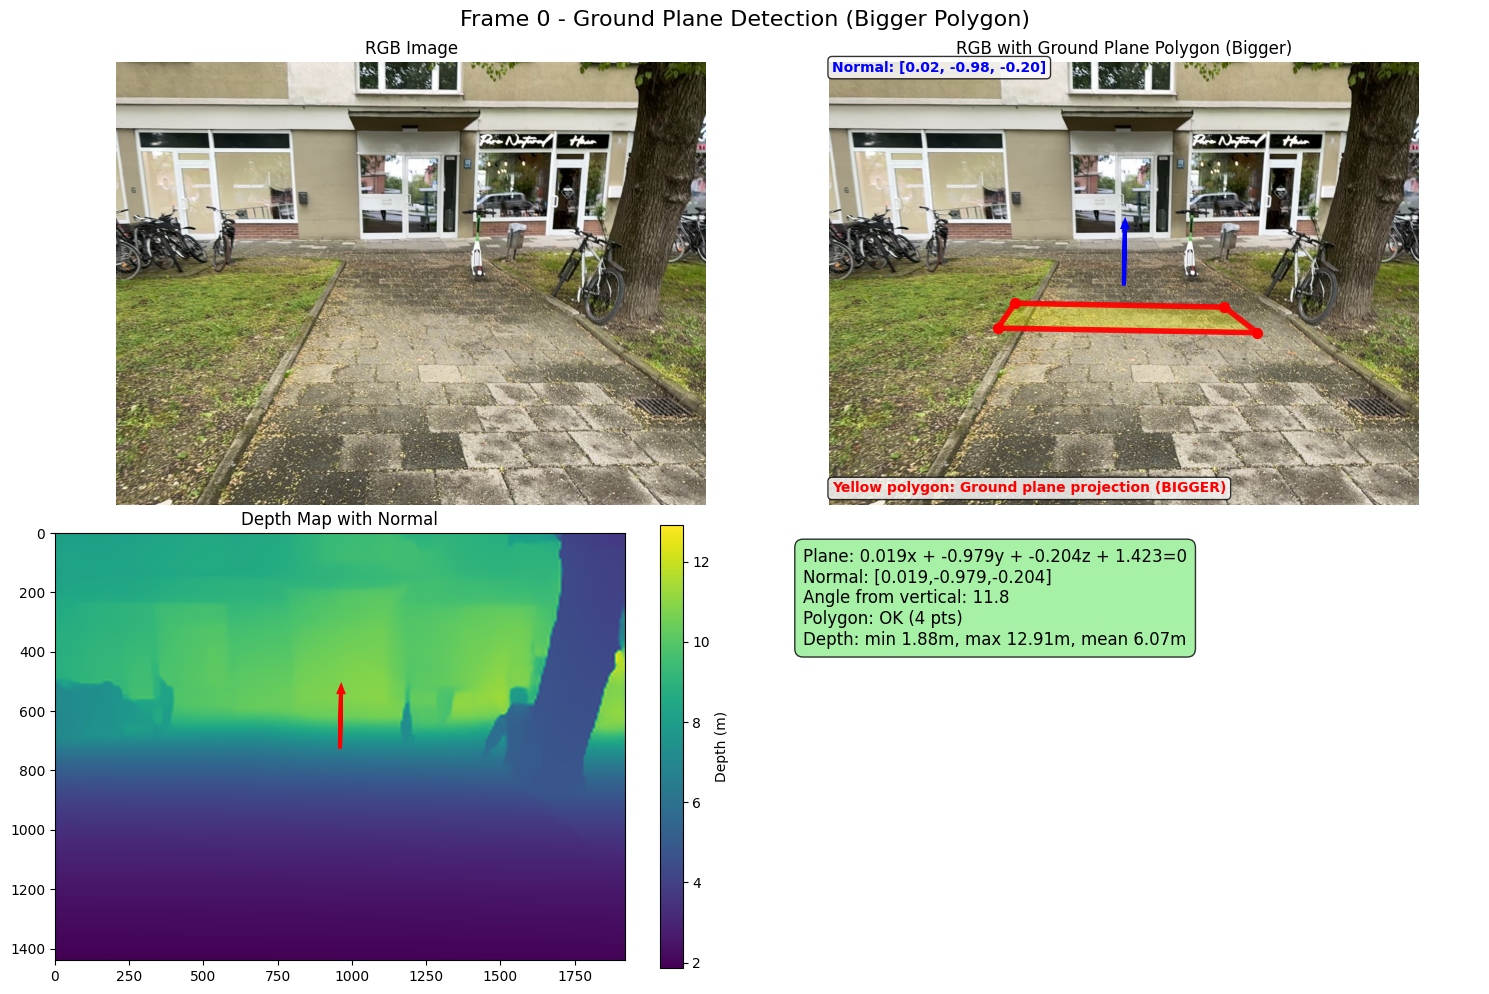

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def create_ground_plane_polygon_simple(normal, d, K, image_shape, center_x, center_y, scale_x = 0.2, scale_y = 24):
    """Simplified version: create polygon by projecting corners at a fixed depth."""
    h, w = image_shape
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    # Use a reasonable depth for visualization (e.g., 3 meters)
    depth = 5.0

    # 🔧 MAKE POLYGON BIGGER: Increase these offset values
    max_offset_x = int(w * scale_x)
    max_offset_y = int(h * scale_y)

    image_corners = [
        [center_x - max_offset_x, center_y - max_offset_y],
        [center_x + max_offset_x, center_y - max_offset_y],
        [center_x + max_offset_x, center_y + max_offset_y],
        [center_x - max_offset_x, center_y + max_offset_y],
    ]

    polygon_points = []

    for u, v in image_corners:
        # Ensure corners are within image bounds
        u = max(0, min(w-1, u))
        v = max(0, min(h-1, v))

        # Convert to 3D point at the fixed depth
        x_3d = (u - cx) * depth / fx
        y_3d = (v - cy) * depth / fy
        z_3d = depth

        point_3d = np.array([x_3d, y_3d, z_3d])

        # Project this point onto the ground plane
        # Distance from point to plane: normal · point + d
        distance_to_plane = np.dot(normal, point_3d) + d

        # Project point onto plane by moving along normal
        projected_point = point_3d - distance_to_plane * normal

        # Convert back to image coordinates
        if projected_point[2] > 0.1:  # Point is in front of camera
            proj_u = cx + (projected_point[0] / projected_point[2]) * fx
            proj_v = cy + (projected_point[1] / projected_point[2]) * fy

            # Add all points, even if slightly outside bounds for visualization
            polygon_points.append([proj_u, proj_v])

    if len(polygon_points) >= 3:
        return np.array(polygon_points)
    else:
        return None


# ─── Main plotting routine ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Frame {frame_idx} - Ground Plane Detection (Bigger Polygon)', fontsize=16)

rgb_array   = np.array(frame_data.rgb_image)
depth_array = np.array(frame_data.depth_image)
h, w        = depth_array.shape

# 1) RGB image
axes[0,0].imshow(rgb_array)
axes[0,0].set_title('RGB Image')
axes[0,0].axis('off')

# 2) RGB + polygon + **scaled** normal arrow
ax = axes[0,1]
ax.imshow(rgb_array)
ax.set_title('RGB with Ground Plane Polygon (Bigger)')

if frame_data.ground_plane is not None:
    normal, d = frame_data.ground_plane
    K = frame_data.camera_intrinsics

    # draw the polygon at fixed depth (now bigger!)
    cx, cy = w//2, h//2
    polygon = create_ground_plane_polygon_simple(normal, d, K, (h,w), cx, cy, scale_x=0.2, scale_y=0.9)
    if polygon is not None and len(polygon)>=3:
        # Make the polygon more visible with thicker lines and different colors
        patch = Polygon(polygon, closed=True,
                        facecolor='yellow', edgecolor='red',
                        alpha=0.3, linewidth=3)  # Increased linewidth
        ax.add_patch(patch)
        closed = np.vstack([polygon, polygon[0]])
        ax.plot(closed[:,0], closed[:,1], color='red', linewidth=4, alpha=0.9)  # Thicker line

        # Add corner markers to make it more visible
        ax.scatter(polygon[:,0], polygon[:,1], color='red', s=50, zorder=10)

    # ─── compute scaled arrow ────────────────────────────────
    fx, fy = K[0,0], K[1,1]
    # tail at centre
    cx, cy = w//2, h//2

    # 1 metre arrow in 3D
    alpha = 1.0

    # look up the depth at (cx,cy)
    Z0 = depth_array[cy, cx]
    if Z0 <= 0:
        valid = depth_array[depth_array>0]
        Z0 = float(np.median(valid))

    # pixel displacement for a 3D step alpha along the normal
    du = normal[0] * alpha * fx / Z0
    dv = normal[1] * alpha * fy / Z0

    # draw it in blue
    ax.arrow(cx, cy, du, dv,
             head_width=12, head_length=15,
             fc='blue', ec='blue', linewidth=3)

    ax.text(10, 30,
            f'Normal: [{normal[0]:.2f}, {normal[1]:.2f}, {normal[2]:.2f}]',
            color='blue', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.text(10, h-40, 'Yellow polygon: Ground plane projection (BIGGER)',
            color='red', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.axis('off')

# 3) Depth map + **scaled** normal arrow
ax = axes[1,0]
cax = ax.imshow(depth_array, cmap='viridis')
ax.set_title('Depth Map with Normal')

if frame_data.ground_plane is not None:
    normal, d = frame_data.ground_plane
    K = frame_data.camera_intrinsics
    fx, fy = K[0,0], K[1,1]

    # tail at centre
    cx, cy = w//2, h//2

    # 1 metre arrow in 3D
    alpha = 1.0

    Z0 = depth_array[cy, cx]
    if Z0 <= 0:
        valid = depth_array[depth_array>0]
        Z0 = float(np.median(valid))

    du = normal[0] * alpha * fx / Z0
    dv = normal[1] * alpha * fy / Z0

    ax.arrow(cx, cy, du, dv,
             head_width=12, head_length=15,
             fc='red', ec='red', linewidth=3)

plt.colorbar(cax, ax=ax, label='Depth (m)')

# 4) Stats and Information
ax = axes[1,1]
ax.axis('off')

if frame_data.ground_plane is not None:
    normal, d = frame_data.ground_plane

    # Create text information
    angle_from_vertical = np.arccos(abs(normal[1])) * 180 / np.pi
    polygon_status = f"OK ({len(polygon)} pts)" if polygon is not None else "Failed"

    stats = f"""Plane: {normal[0]:.3f}x + {normal[1]:.3f}y + {normal[2]:.3f}z + {d:.3f}=0
Normal: [{normal[0]:.3f},{normal[1]:.3f},{normal[2]:.3f}]
Angle from vertical: {angle_from_vertical:.1f}
Polygon: {polygon_status}
Depth: min {depth_array.min():.2f}m, max {depth_array.max():.2f}m, mean {depth_array.mean():.2f}m"""

    ax.text(0.05, 0.95, stats, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
            facecolor="lightgreen", alpha=0.8))

plt.tight_layout()
plt.show()

In [27]:
dataset[0].camera_pose == dataset[500].camera_pose

Debug: [StrayDataset::__getitem__]: Resizing depth image to match RGB dimensions (256, 192) -> (1920, 1440)

array([[False, False, False, False],
       [False, False, False, False],
       [False, False, False, False],
       [ True,  True,  True,  True]])